In [1]:
from eccodes import *
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
import cartopy.crs as crs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.shapereader as shapereader
from datetime import  datetime, timedelta
import os ,sys
import cmaps

In [2]:
fn =  f"E:/000_FuJian/fnl/gdas1.fnl0p25.2024040500.f00.grib2"
ds = xr.open_dataset(fn, engine='cfgrib',backend_kwargs={'filter_by_keys': {'name': '2 metre temperature'}})
ds 

D:\conda\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated and will be removed in a future release
  "class": algorithms.Blowfish,


<xarray.Dataset>
Dimensions:            (latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] ...
    step               timedelta64[ns] ...
    heightAboveGround  float64 ...
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 0.0 0.25 0.5 ... 359.2 359.5 359.8
    valid_time         datetime64[ns] ...
Data variables:
    t2m                (latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2024-05-11T15:43 GRIB to CDM+CF via cfgrib-0.9.1...

AttributeError: 'Dataset' object has no attribute 't2m'

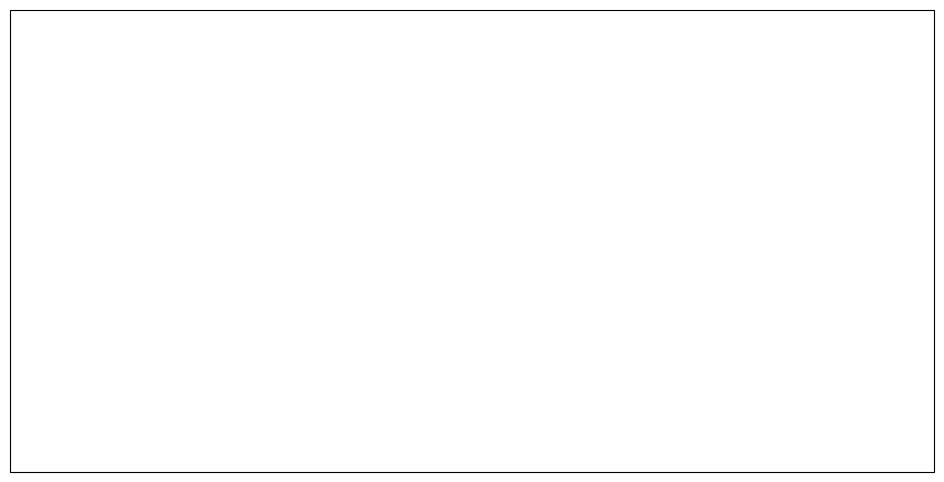

In [7]:
cart_proj = crs.PlateCarree()
fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=cart_proj)

levels = np.linspace(-10,30,41,endpoint=True)
t2 = plt.contourf(ds.longitude, ds.latitude, ds.t2m - 273.15, levels=levels,cmap=cmaps.NCV_jet,
                  transform=crs.PlateCarree())
cb = fig.colorbar(t2, ax=ax, orientation="vertical", pad=.05, shrink=.90,) # spacing="proportional"
extent=[115.5,120.5,23.5,28.5]  ## 经纬度范围 [西，东，南，北]
ax.set_extent(extent)
gl = ax.gridlines(crs=crs.PlateCarree(),draw_labels=True,linewidth=1.2, color='k', alpha=0.1, linestyle='--')
gl.top_labels   = False    #关闭顶端标签
gl.right_labels = False  #关闭右侧标签
gl.xformatter = LONGITUDE_FORMATTER  #x轴设为经度格式
gl.yformatter = LATITUDE_FORMATTER   #y轴设为纬度格式
mfl    =r"C:/Users/xmxm/Desktop/slt/fj_qufan.shp"
ax.add_geometries(shapereader.Reader(mfl).geometries(), crs=cart_proj, facecolor='none',edgecolor='k',linewidth=0.5)

In [4]:
ds = xr.open_dataset(fn, engine='cfgrib',backend_kwargs={'filter_by_keys': {'typeOfLevel': 'heightAboveGround'}})
ds 

skipping variable: paramId==167 shortName='t2m'
Traceback (most recent call last):
  File "C:\Users\xmxm\AppData\Roaming\Python\Python311\site-packages\cfgrib\dataset.py", line 701, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\xmxm\AppData\Roaming\Python\Python311\site-packages\cfgrib\dataset.py", line 629, in dict_merge
    raise DatasetBuildError(
cfgrib.dataset.DatasetBuildError: key present and new value is different: key='heightAboveGround' value=Variable(dimensions=('heightAboveGround',), data=array([1000., 4000.])) new_value=Variable(dimensions=(), data=2.0)
skipping variable: paramId==174096 shortName='sh2'
Traceback (most recent call last):
  File "C:\Users\xmxm\AppData\Roaming\Python\Python311\site-packages\cfgrib\dataset.py", line 701, in build_dataset_components
    dict_merge(variables, coord_vars)
  File "C:\Users\xmxm\AppData\Roaming\Python\Python311\site-packages\cfgrib\dataset.py", line 629, in dict_merge
    raise DatasetBuildErro

<xarray.Dataset>
Dimensions:            (heightAboveGround: 2, latitude: 721, longitude: 1440)
Coordinates:
    time               datetime64[ns] ...
    step               timedelta64[ns] ...
  * heightAboveGround  (heightAboveGround) float64 1e+03 4e+03
  * latitude           (latitude) float64 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude          (longitude) float64 0.0 0.25 0.5 ... 359.2 359.5 359.8
    valid_time         datetime64[ns] ...
Data variables:
    refd               (heightAboveGround, latitude, longitude) float32 ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2024-05-11T15:44 GRIB to CDM+CF via cfgrib-0.9.1...

AttributeError: 'Dataset' object has no attribute 'u10'

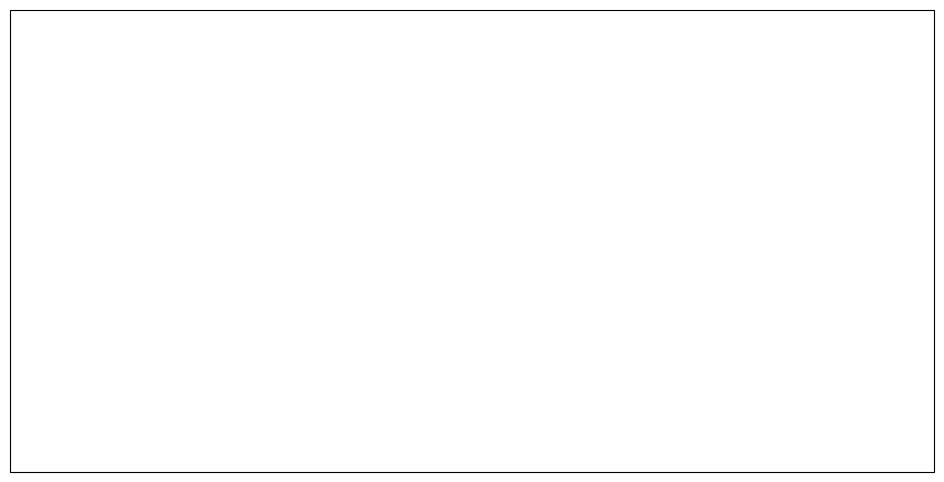

In [5]:
cart_proj = crs.PlateCarree()
fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=cart_proj)

levels = np.linspace(0,20,21,endpoint=True)
wspd = np.sqrt(ds.u10 **2 + ds.v10**2)
wnd = plt.contourf(ds.longitude, ds.latitude, wspd, levels=levels,cmap=cmaps.WhiteBlueGreenYellowRed,
                  transform=crs.PlateCarree())
cb = fig.colorbar(wnd, ax=ax, orientation="vertical", pad=.05, shrink=.90,) # spacing="proportional"
step = 5
wbar = ax.barbs(ds.longitude[::step], ds.latitude[::step],
            ds.u10[::step, ::step],ds.v10[::step, ::step],
      barb_increments={'half':2,'full':4,'flag':20},barbcolor="gray",
      transform=crs.PlateCarree(), length=5)
extent=[115.5,120.5,23.5,28.5]  ## 经纬度范围 [西，东，南，北]
ax.set_extent(extent)
gl = ax.gridlines(crs=crs.PlateCarree(),draw_labels=True,linewidth=1.2, color='k', alpha=0.1, linestyle='--')
gl.top_labels   = False    #关闭顶端标签
gl.right_labels = False  #关闭右侧标签
gl.xformatter = LONGITUDE_FORMATTER  #x轴设为经度格式
gl.yformatter = LATITUDE_FORMATTER   #y轴设为纬度格式

mfl    = r"E:/0_ditudate/矢量图/和鲸矢量图/province_9south.shp"
ax.add_geometries(shapereader.Reader(mfl).geometries(), crs=cart_proj, facecolor='none',edgecolor='k',linewidth=0.5)